<a href="https://colab.research.google.com/github/Poojan0922/Collab/blob/main/predicting_stars_galaxies_quasars_with_ml_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# About the data:

### From the Overview section,

"The data consists of 10,000 observations of space taken by the SDSS. Every observation is described by 17 feature columns and 1 class column which identifies it to be either a star, galaxy or quasar."20% used in testing and 80% in training.


# Overview of Data
### Labels

So what exactly are stars, galaxies, and quasars?


*     A GALAXY is a gravitationally bound system of stars, stellar remnants, interstellar gas, dust, and dark matter. Galaxies are categorised according to their visual morphology as elliptical, spiral, or irregular. Many galaxies are thought to have supermassive black holes at their active centers.
*     A STAR is a type of astronomical object consisting of a luminous spheroid of plasma held together by its own gravity. The nearest star to Earth is the Sun.
*     A QUASAR, also known as quasi-stellar object, is an extremely luminous active galactic nucleus (AGN). The power radiated by quasars is enormous. The most powerful quasars have luminosities exceeding 1041 watts, thousands of times greater than an ordinary large galaxy such as the Milky Way.

# Features

### A summary of the more important features are:

*     ra, dec — right ascension and declination respectively
*     u, g, r, i, z — filter bands (a.k.a. photometric system or astronomical magnitudes)
*     run, rerun, camcol, field — descriptors of fields (i.e. 2048 x 1489 pixels) within image
*     redshift — increase in wavelength due to motion of astronomical object
*     plate — plate number
*     mjd — modified Julian date of observation
*     fiberid — optic fiber ID

In [ ]:
import numpy as np
import pandas as pd




#### first of all we need to import all the packages we need. Numpy and Pandas for data manipulation and all the modules from sklearn


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from tensorflow import keras
%matplotlib inline

# Exploratory Analysis

#### Loading Data

In [ ]:
data = pd.read_csv("/content/Skyserver_SQL2_27_2018 6_51_39 PM.csv.zip")

In [ ]:
data.head()

,objid,ra,dec,u,g,r,i,z,run,rerun,camcol,field,specobjid,class,redshift,plate,mjd,fiberid
0,1.237650e+18,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,752,301,4,267,3.722360e+18,STAR,-0.000009,3306,54922,491
1,1.237650e+18,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,752,301,4,267,3.638140e+17,STAR,-0.000055,323,51615,541
2,1.237650e+18,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,752,301,4,268,3.232740e+17,GALAXY,0.123111,287,52023,513
3,1.237650e+18,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,752,301,4,269,3.722370e+18,STAR,-0.000111,3306,54922,510
4,1.237650e+18,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,752,301,4,269,3.722370e+18,STAR,0.000590,3306,54922,512


In [ ]:
data.shape

(10000, 18)

#### The object id columns, they are of no use in the analysis so we will delete them from dataset

In [ ]:
# drop the object id columns, they are of no use in the analysis
data.drop(['objid','specobjid','ra','dec','run','rerun','camcol','field','plate','mjd','fiberid'], axis=1, inplace=True)

Data after droping columns

In [ ]:
data.head(10)

,u,g,r,i,z,class,redshift
0,19.47406,17.04240,15.94699,15.50342,15.22531,STAR,-0.000009
1,18.66280,17.21449,16.67637,16.48922,16.39150,STAR,-0.000055
2,19.38298,18.19169,17.47428,17.08732,16.80125,GALAXY,0.123111
3,17.76536,16.60272,16.16116,15.98233,15.90438,STAR,-0.000111
4,17.55025,16.26342,16.43869,16.55492,16.61326,STAR,0.000590
5,19.43133,18.46779,18.16451,18.01475,18.04155,STAR,0.000315
6,19.38322,17.88995,17.10537,16.66393,16.36955,GALAXY,0.100242
7,18.97993,17.84496,17.38022,17.20673,17.07071,STAR,0.000315
8,17.90616,16.97172,16.67541,16.53776,16.47596,STAR,0.000089
9,18.67249,17.71375,17.49362,17.28284,17.22644,GALAXY,0.040508


In [ ]:
data.shape

(10000, 7)

In [ ]:
tab = data.describe()
tab.round(decimals=4)

,u,g,r,i,z,redshift
count,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000
mean,18.6194,17.3719,16.8410,16.5836,16.4228,0.1437
std,0.8287,0.9455,1.0678,1.1418,1.2032,0.3888
min,12.9890,12.7996,12.4316,11.9472,11.6104,-0.0041
25%,18.1780,16.8151,16.1733,15.8537,15.6183,0.0001
50%,18.8531,17.4951,16.8588,16.5550,16.3899,0.0426
75%,19.2592,18.0101,17.5127,17.2586,17.1414,0.0926
max,19.5999,19.9190,24.8020,28.1796,22.8331,5.3539


check the Null values

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   u         10000 non-null  float64
 1   g         10000 non-null  float64
 2   r         10000 non-null  float64
 3   i         10000 non-null  float64
 4   z         10000 non-null  float64
 5   class     10000 non-null  object 
 6   redshift  10000 non-null  float64
dtypes: float64(6), object(1)
memory usage: 547.0+ KB


No missing data

### The Target from data is Data classification to Star,Galaxy or Quasar,so the class column has 3 Categories and in this case we need to convert them into numeric data.

In [ ]:
le = LabelEncoder().fit(data['class'])
data['class'] = le.transform(data['class'])

# The result

In [ ]:
data.head(10)

,u,g,r,i,z,class,redshift
0,19.47406,17.04240,15.94699,15.50342,15.22531,2,-0.000009
1,18.66280,17.21449,16.67637,16.48922,16.39150,2,-0.000055
2,19.38298,18.19169,17.47428,17.08732,16.80125,0,0.123111
3,17.76536,16.60272,16.16116,15.98233,15.90438,2,-0.000111
4,17.55025,16.26342,16.43869,16.55492,16.61326,2,0.000590
5,19.43133,18.46779,18.16451,18.01475,18.04155,2,0.000315
6,19.38322,17.88995,17.10537,16.66393,16.36955,0,0.100242
7,18.97993,17.84496,17.38022,17.20673,17.07071,2,0.000315
8,17.90616,16.97172,16.67541,16.53776,16.47596,2,0.000089
9,18.67249,17.71375,17.49362,17.28284,17.22644,0,0.040508


after lable encoding,the galaxy has been replaced by number 0, the Quasar is number 1 and star is number 2

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   u         10000 non-null  float64
 1   g         10000 non-null  float64
 2   r         10000 non-null  float64
 3   i         10000 non-null  float64
 4   z         10000 non-null  float64
 5   class     10000 non-null  int64  
 6   redshift  10000 non-null  float64
dtypes: float64(6), int64(1)
memory usage: 547.0 KB


Perform train and test split

In [ ]:
X = data.drop('class', axis=1)
y = data['class']

# Data Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler(copy=True , with_mean= True , with_std = True)
X= scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=128)

# Density Distribution Plots

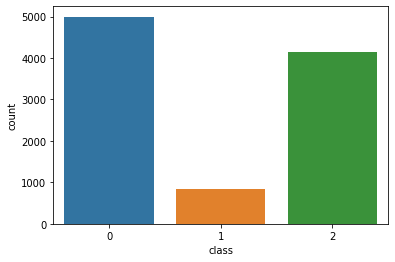

In [ ]:
sns.countplot(x=data['class'])

Definitely:
0 = Galaxy,
1 = Quasar,
2 = Star.

### Some information about filter:
"U" stands for ultraviolet.
"G" stands for green.
"R" stands for red.
"I" stands for infrared.

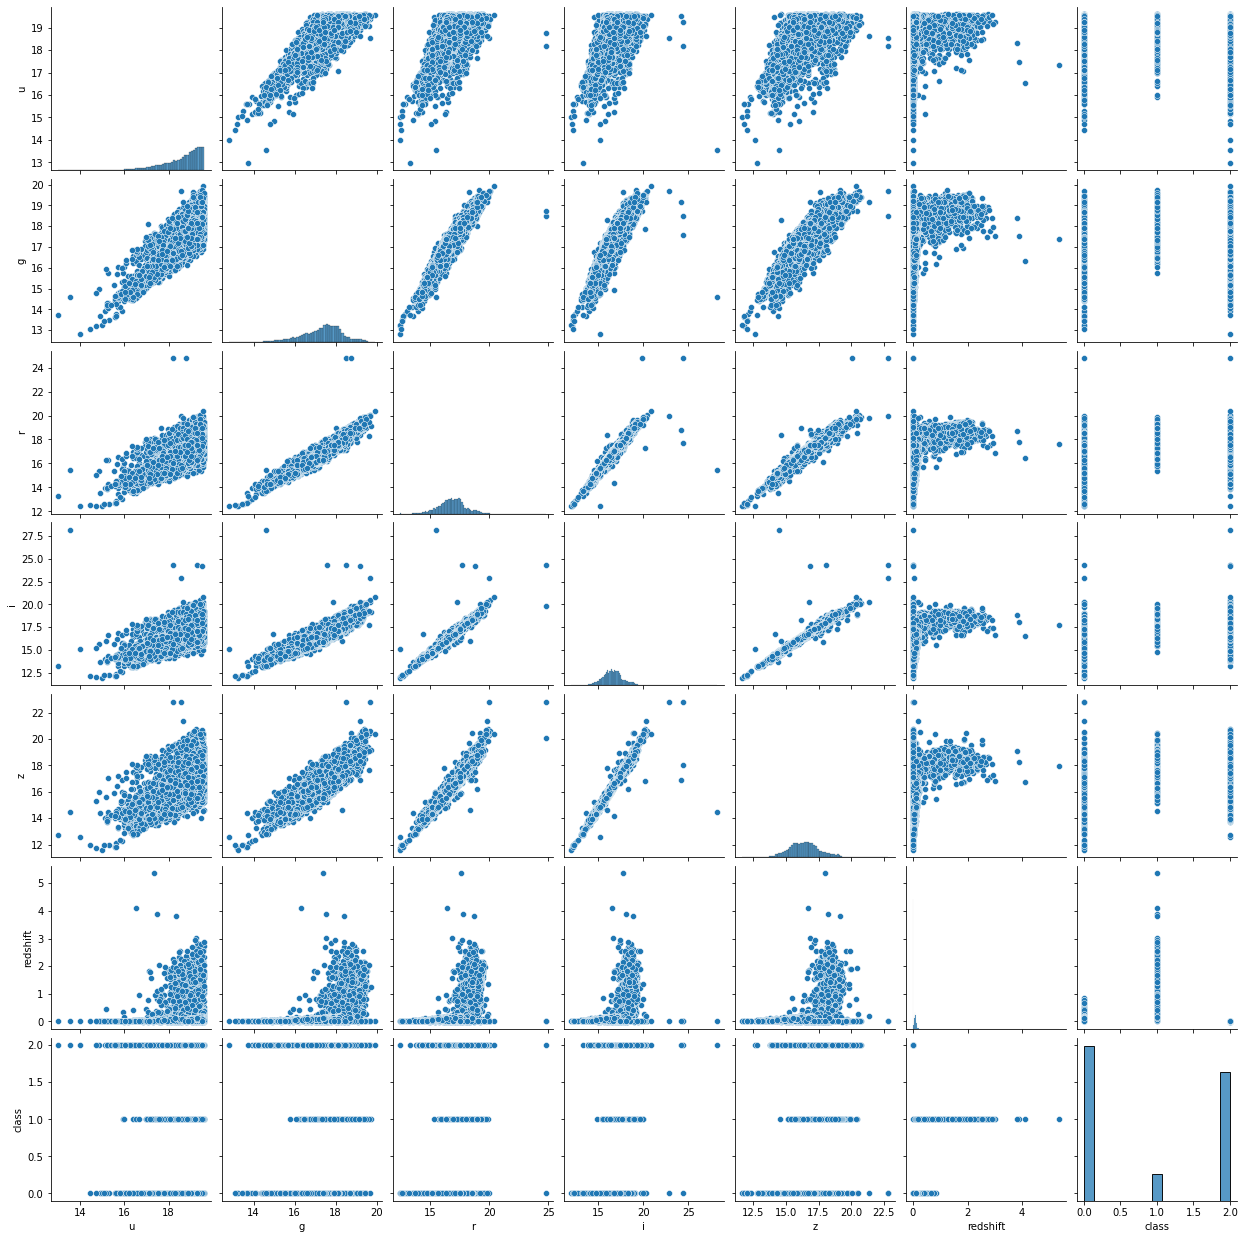

In [ ]:


sns.pairplot(data[['u','g','r','i','z','redshift','class']])



# Machine Learning models(Classification models)

In [ ]:
# Decision Tree Classifier
dtClassifier = DecisionTreeClassifier(max_leaf_nodes=15,max_depth=3)
#------------------------------------------------------------------
#Linear Classifiers:
# 1- Logistic Regression
LRClassifier = LogisticRegression(multi_class='multinomial', solver='lbfgs',class_weight='balanced',max_iter=10000000)
#-------------------------------------------------------------------
#Nearest Neighbor Classifier
NeNeClassifier = KNeighborsClassifier(n_neighbors=3)
#-------------------------------------------------------------------
#Support Vector Machines Classifer
SVCModel = SVC()




In [ ]:
dtClassifier.fit(X_train, y_train)
LRClassifier.fit(X_train, y_train)
NeNeClassifier.fit(X_train, y_train)
SVCModel.fit(X_train, y_train)

SVC()

In [ ]:
y_preds = dtClassifier.predict(X_test)
y_predsLR = LRClassifier.predict(X_test)
y_predsNeNe = NeNeClassifier.predict(X_test)
y_predsSVC = SVCModel.predict(X_test)

In [ ]:
print(y_preds[:10],'\n',y_test[:10])
print("*******************************************************")
print(y_predsLR[:10],'\n',y_test[:10])
print("*******************************************************")
print(y_predsNeNe[:10],'\n',y_test[:10])
print("*******************************************************")
print(y_predsSVC[:10],'\n',y_test[:10])

[2 0 2 2 0 0 2 1 0 0] 
 7054    2
4692    0
907     2
4498    2
9957    0
3341    0
7152    2
1152    1
7105    0
2066    0
Name: class, dtype: int64
*******************************************************
[2 0 2 2 0 0 2 1 0 0] 
 7054    2
4692    0
907     2
4498    2
9957    0
3341    0
7152    2
1152    1
7105    0
2066    0
Name: class, dtype: int64
*******************************************************
[2 0 2 2 0 0 2 1 0 0] 
 7054    2
4692    0
907     2
4498    2
9957    0
3341    0
7152    2
1152    1
7105    0
2066    0
Name: class, dtype: int64
*******************************************************
[2 0 2 2 0 0 2 1 0 0] 
 7054    2
4692    0
907     2
4498    2
9957    0
3341    0
7152    2
1152    1
7105    0
2066    0
Name: class, dtype: int64



### Measure accuracy of the classifier


In [ ]:
print('accuracy_score by Decision Tree Classifier:',accuracy_score(y_true=y_test, y_pred=y_preds))
print('accuracy_score by LR Classifier:',accuracy_score(y_true=y_test, y_pred=y_predsLR))
print('accuracy_score by Nearest Neighbor Classifier:',accuracy_score(y_true=y_test, y_pred=y_predsNeNe))
print('accuracy_score by SVM Classifier:',accuracy_score(y_true=y_test, y_pred=y_predsSVC))

accuracy_score by Decision Tree Classifier: 0.988
accuracy_score by LR Classifier: 0.967
accuracy_score by Nearest Neighbor Classifier: 0.9655
accuracy_score by SVM Classifier: 0.972


### Measure Precision of the classifiers

In [ ]:
print('Precision Score of the Decision Tree classifier is:', precision_score(y_true=y_test, y_pred=y_preds,average='weighted'))
print('Precision Score of the LR classifier is:', precision_score(y_true=y_test, y_pred=y_predsLR,average='weighted'))
print('Precision Score of the Nearest Neighbour classifier is:', precision_score(y_true=y_test, y_pred=y_predsNeNe,average='weighted'))
print('Precision Score of the SVM classifier is:', precision_score(y_true=y_test, y_pred=y_predsSVC,average='weighted'))

Precision Score of the Decision Tree classifier is: 0.9879311977429853
Precision Score of the LR classifier is: 0.967959100110472
Precision Score of the Nearest Neighbour classifier is: 0.9659452633080071
Precision Score of the SVM classifier is: 0.9724817443609022


### Measuring Recall of the classifiers

In [ ]:
print('Recall Score of the Decision Tree classifier is:', recall_score(y_true=y_test, y_pred=y_preds,average='weighted'))
print('Recall Score of the LR classifier is:', recall_score(y_true=y_test, y_pred=y_predsLR,average='weighted'))
print('Recall Score of the Nearest Neighbour classifier is:', recall_score(y_true=y_test, y_pred=y_predsNeNe,average='weighted'))
print('Recall Score of the SVM classifier is:', recall_score(y_true=y_test, y_pred=y_predsSVC,average='weighted'))

Recall Score of the Decision Tree classifier is: 0.988
Recall Score of the LR classifier is: 0.967
Recall Score of the Nearest Neighbour classifier is: 0.9655
Recall Score of the SVM classifier is: 0.972


### Measuring F1 score of the classifiers

In [ ]:
print('F1 Score of the Decision Tree classifier is:', f1_score(y_true=y_test, y_pred=y_preds,average='weighted'))
print('F1 Score of the LR classifier is:', f1_score(y_true=y_test, y_pred=y_predsLR,average='weighted'))
print('F1 Score of the Nearest Neighbour classifier is:', f1_score(y_true=y_test, y_pred=y_predsNeNe,average='weighted'))
print('F1 Score of the SVM classifier is:', f1_score(y_true=y_test, y_pred=y_predsSVC,average='weighted'))

F1 Score of the Decision Tree classifier is: 0.9879046221966391
F1 Score of the LR classifier is: 0.9669975721152704
F1 Score of the Nearest Neighbour classifier is: 0.9654832732673893
F1 Score of the SVM classifier is: 0.9719293194518012


### **Classification Report**

In [ ]:
print('Classification Report of the Decision Tree classifier :\n\n',classification_report(y_true=y_test, y_pred=y_preds))
print("*******************************************************")
print('Classification Report of the LR classifier :\n\n',classification_report(y_true=y_test, y_pred=y_predsLR))
print("*******************************************************")
print('Classification Report of the KNN classifier :\n\n',classification_report(y_true=y_test, y_pred=y_predsNeNe))
print("*******************************************************")
print('Classification Report of the SVM classifier :\n\n',classification_report(y_true=y_test, y_pred=y_predsSVC))

Classification Report of the Decision Tree classifier :

               precision    recall  f1-score   support

           0       0.98      0.99      0.99       973
           1       0.97      0.92      0.95       186
           2       1.00      1.00      1.00       841

    accuracy                           0.99      2000
   macro avg       0.98      0.97      0.98      2000
weighted avg       0.99      0.99      0.99      2000

*******************************************************
Classification Report of the LR classifier :

               precision    recall  f1-score   support

           0       0.99      0.95      0.97       973
           1       0.95      0.97      0.96       186
           2       0.95      0.99      0.97       841

    accuracy                           0.97      2000
   macro avg       0.96      0.97      0.96      2000
weighted avg       0.97      0.97      0.97      2000

*******************************************************
Classification Report

#**BUILD STACKED MODEL**

In [ ]:
from sklearn.ensemble import StackingClassifier

estimator_list =[
    ('LRClassifier',dtClassifier),
    ('NeNeClassifier',NeNeClassifier),
    ('SVCModel',SVCModel) ]

# Build stack model
stack_model = StackingClassifier(
    estimators=estimator_list, final_estimator=LogisticRegression(max_iter=10000000)
)

# Train stacked model
stack_model.fit(X_train,y_train)

# Make prediction
y_predsStack = stack_model.predict(X_test)

In [ ]:
print(y_predsStack[:10],'\n',y_test[:10])

[2 0 2 2 0 0 2 1 0 0] 
 7054    2
4692    0
907     2
4498    2
9957    0
3341    0
7152    2
1152    1
7105    0
2066    0
Name: class, dtype: int64


In [ ]:
print('accuracy_score of Stacked Classifier :',accuracy_score(y_true=y_test, y_pred=y_predsStack))
print('Precision Score of the Stacked classifier is:', precision_score(y_true=y_test, y_pred=y_predsStack,average='weighted'))
print('Recall Score of the Stacked classifier is:', recall_score(y_true=y_test, y_pred=y_predsStack,average='weighted'))
print('F1 Score of the Stacked classifier is:', f1_score(y_true=y_test, y_pred=y_predsStack,average='weighted'))

accuracy_score of Stacked Classifier : 0.991
Precision Score of the Stacked classifier is: 0.9909967546437117
Recall Score of the Stacked classifier is: 0.991
F1 Score of the Stacked classifier is: 0.9909364359351978


In [ ]:
print('Classification Report of the Stacked classifier :\n\n',classification_report(y_true=y_test, y_pred=y_predsStack))

Classification Report of the Stacked classifier :

               precision    recall  f1-score   support

           0       0.99      0.99      0.99       973
           1       0.99      0.94      0.96       186
           2       1.00      1.00      1.00       841

    accuracy                           0.99      2000
   macro avg       0.99      0.98      0.98      2000
weighted avg       0.99      0.99      0.99      2000



# **Boosting models**

**AdaBoost**

In [ ]:
from sklearn.ensemble import AdaBoostClassifier

In [ ]:
AdaModel = AdaBoostClassifier(n_estimators=150,base_estimator=LRClassifier,learning_rate=1)

In [ ]:
# train AdaModel
modelboost = AdaModel.fit(X_train,y_train)

# predicting trained model
y_pred_boost = modelboost.predict(X_test)

In [ ]:
print('accuracy_score of Boosting Classifier AdaBoost:',accuracy_score(y_true=y_test, y_pred=y_pred_boost))
print('Precision Score of the Boosted classifier AdaBoost is:', precision_score(y_true=y_test, y_pred=y_pred_boost,average='weighted'))
print('Recall Score of the Boosted classifier AdaBoost is:', recall_score(y_true=y_test, y_pred=y_pred_boost,average='weighted'))
print('F1 Score of the Boosted classifier AdaBoost is:', f1_score(y_true=y_test, y_pred=y_pred_boost,average='weighted'))

accuracy_score of Boosting Classifier AdaBoost: 0.8695
Precision Score of the Boosted classifier AdaBoost is: 0.8830499276687013
Recall Score of the Boosted classifier AdaBoost is: 0.8695
F1 Score of the Boosted classifier AdaBoost is: 0.8677052815012312


In [ ]:
print('Classification Report of the AdaBoost classifier :\n\n',classification_report(y_true=y_test, y_pred=y_pred_boost))

Classification Report of the AdaBoost classifier :

               precision    recall  f1-score   support

           0       0.81      0.96      0.88       973
           1       0.97      0.93      0.95       186
           2       0.95      0.75      0.84       841

    accuracy                           0.87      2000
   macro avg       0.91      0.88      0.89      2000
weighted avg       0.88      0.87      0.87      2000



**XGBoost**

In [ ]:
import xgboost as xgb
xgb_model = xgb.XGBClassifier(learning_rate=0.001, max_depth=1, n_estimators=100)

# train xgb_model
modelboost2 = xgb_model.fit(X_train, y_train)
# predict trained mlodel
y_pred_boost2 = modelboost2.predict(X_test)

In [ ]:
print('accuracy_score by Boosting Classifier XGBoost:',accuracy_score(y_true=y_test, y_pred=y_pred_boost2))
print('Precision Score of the Boosted classifier XGBoost is:', precision_score(y_true=y_test, y_pred=y_pred_boost2,average='weighted'))
print('Recall Score of the Boosted classifier XGBoost is:', recall_score(y_true=y_test, y_pred=y_pred_boost2,average='weighted'))
print('F1 Score of the Boosted classifier XGBoost is:', f1_score(y_true=y_test, y_pred=y_pred_boost2,average='weighted'))

accuracy_score by Boosting Classifier XGBoost: 0.988
Precision Score of the Boosted classifier XGBoost is: 0.9879311977429853
Recall Score of the Boosted classifier XGBoost is: 0.988
F1 Score of the Boosted classifier XGBoost is: 0.9879046221966391


In [ ]:
print('Classification Report of the XGBoost classifier :\n\n',classification_report(y_true=y_test, y_pred=y_pred_boost2))

Classification Report of the XGBoost classifier :

               precision    recall  f1-score   support

           0       0.98      0.99      0.99       973
           1       0.97      0.92      0.95       186
           2       1.00      1.00      1.00       841

    accuracy                           0.99      2000
   macro avg       0.98      0.97      0.98      2000
weighted avg       0.99      0.99      0.99      2000



In [ ]:
Models = ["DT","DT","DT","LR","LR","LR","KNN","KNN","KNN","SVM","SVM","SVM","Stacked","Stacked","Stacked","AdaBoost","AdaBoost","AdaBoost","XGBoost","XGBoost","XGBoost"]
Precision = [0.98,0.97,1.00,0.99,0.96,0.96,0.89,0.97,0.93,0.95,0.99,0.96,0.99,0.99,1.00,0.86,0.96,0.97,0.98,0.97,1.00]
Recall = [0.99,0.92,1.00,0.96,0.96,0.99,0.95,0.88,0.89,0.97,0.92,0.96,0.99,0.93,1.00,0.97,0.94,0.83,0.99,0.92,1.00]
F1 = [0.99,0.95,1.00,0.98,0.96,0.98,0.92,0.92,0.91,0.96,0.95,0.96,0.99,0.96,1.00,0.91,0.95,0.90,0.99,0.95,1.00]
Macro_avg = [0.98,0.97,0.98,0.97,0.97,0.97,0.93,0.90,0.92,0.97,0.95,0.96,0.99,0.97,0.98,0.93,0.91,0.92,0.98,0.97,0.98]
Weighted_avg = [0.99,0.99,0.99,0.97,0.97,0.97,0.92,0.92,0.92,0.96,0.96,0.96,0.99,0.99,0.99,0.92,0.91,0.91,0.99,0.99,0.99]

Evaluation = pd.DataFrame([Models,Precision,Recall,F1,Macro_avg,Weighted_avg],index = ["Models","Precision","Recall","F1","Macro_avg","Weighted_avg"])
Evaluation = Evaluation.T
Evaluation


,Models,Precision,Recall,F1,Macro_avg,Weighted_avg
0,DT,0.98,0.99,0.99,0.98,0.99
1,DT,0.97,0.92,0.95,0.97,0.99
2,DT,1.0,1.0,1.0,0.98,0.99
3,LR,0.99,0.96,0.98,0.97,0.97
4,LR,0.96,0.96,0.96,0.97,0.97
5,LR,0.96,0.99,0.98,0.97,0.97
6,KNN,0.89,0.95,0.92,0.93,0.92
7,KNN,0.97,0.88,0.92,0.9,0.92
8,KNN,0.93,0.89,0.91,0.92,0.92
9,SVM,0.95,0.97,0.96,0.97,0.96


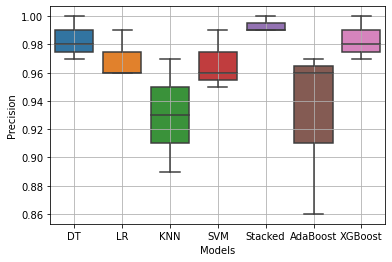

In [ ]:
sns.boxplot(x="Models",y="Precision",data=Evaluation)
plt.grid(b=True)
plt.show()

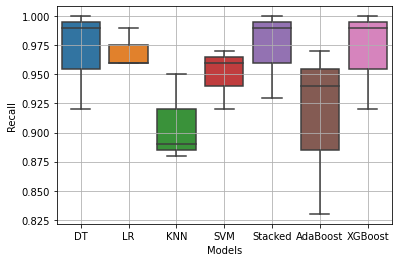

In [ ]:
sns.boxplot(x="Models",y="Recall",data=Evaluation)
plt.grid(b=True)
plt.show()

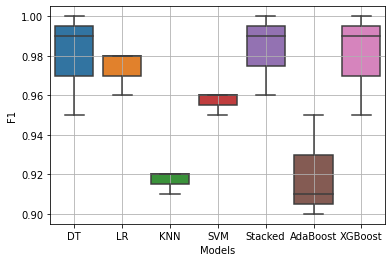

In [ ]:
sns.boxplot(x="Models",y="F1",data=Evaluation)
plt.grid(b=True)
plt.show()

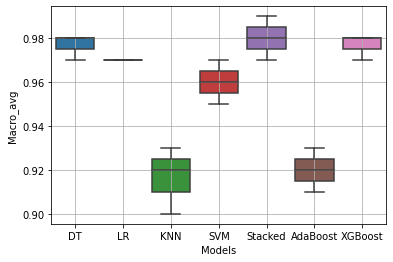

In [ ]:
sns.boxplot(x="Models",y="Macro_avg",data=Evaluation)
plt.grid(b=True)
plt.show()

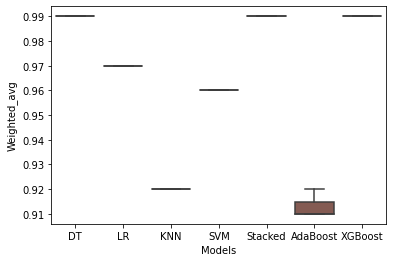

In [ ]:
sns.boxplot(x="Models",y="Weighted_avg",data=Evaluation)